In [3]:
import sys
!{sys.executable} -m pip install lightgbm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
print(sys.executable)

c:\Users\82105\Desktop\it-s_advanced_project\.venv\Scripts\python.exe


In [5]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency  

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay
from lightgbm import LGBMClassifier

import scikit_posthocs as sp

from unidecode import unidecode
import geopandas as gpd
import sys
import os

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # 모든 컬럼이 다 보인다.
pd.set_option('display.max_rows', 100) # 행 출력 개수 제한

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [6]:
# 데이터 로드 & 정제

all = pd.read_csv('../data/olist_preprocess_ver2_data.csv')
geo = pd.read_csv('../data/geolocation_clean.csv')
df= all.copy()
# print(df.shape[0], 'rows × ', df.shape[1], 'columns')
# 111495 rows ×  29 columns

# 날짜 칼럼 변환
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 배송 완료된 주문건만 대상로
df = df[
    (df['order_delivered_customer_date'] != pd.Timestamp('2099-01-01')) &  #두 조건 동일행 의미
    (df['order_status'] == 'delivered')
]
# removed rows: 1881
# remaining rows: 10961

In [7]:
# 지리적 정보 병합 및 거리 계산
# 하버사인 공식으로 두 점 사이의 거리 계산
def calculate_distance(lat1, lng1, lat2, lng2):
    R = 6371  # 지구의 반지름 (km)
    
    lat1_rad = np.radians(lat1)
    lng1_rad = np.radians(lng1)
    lat2_rad = np.radians(lat2)
    lng2_rad = np.radians(lng2)
    
    dlat = lat2_rad - lat1_rad
    dlng = lng2_rad - lng1_rad
    
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlng/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# 고객 위치 좌표 병합
geo_customer = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

geo_customer.columns = ['customer_zip_code_prefix', 'customer_lat', 'customer_lng']
df_merged = df.merge(geo_customer, on='customer_zip_code_prefix', how='left')

# 판매자 위치 좌표 병합
geo_seller = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

geo_seller.columns = ['seller_zip_code_prefix', 'seller_lat', 'seller_lng']
df_merged = df_merged.merge(geo_seller, on='seller_zip_code_prefix', how='left')

# 각 주문에 대해 고객과 판매자 사이의 거리 계산
distances = []
for index, row in df_merged.iterrows():
    if pd.notna(row['seller_lat']) and pd.notna(row['customer_lat']):
        dist = calculate_distance(
            row['seller_lat'], row['seller_lng'],
            row['customer_lat'], row['customer_lng']
        )
        distances.append(dist)
    else:
        distances.append(None)

df_merged['actual_distance_km'] = distances

# 거리 정보가 없는 행 제거
df_merged = df_merged.dropna(subset=['actual_distance_km'])

In [8]:
# 상품 부피 계산
df_merged['product_volume'] = (
    df_merged['product_length_cm'] * 
    df_merged['product_height_cm'] * 
    df_merged['product_width_cm']
)

# 주문 월과 요일 추출
df_merged['order_month'] = df_merged['order_purchase_timestamp'].dt.month
df_merged['order_dayofweek'] = df_merged['order_purchase_timestamp'].dt.dayofweek

# 튜터님이 주신 month 해결 코드
df_merged['order_month_sin'] = np.sin(2 * np.pi * df_merged['order_month'] / 12)
df_merged['order_month_cos'] = np.cos(2 * np.pi * df_merged['order_month'] / 12)

# 시즌 결정 함수
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

# 각 주문의 시즌 결정
seasons = []
for month in df_merged['order_month']:
    season = get_season(month)
    seasons.append(season)

df_merged['season'] = seasons

# 주말 여부 결정 (토요일=5, 일요일=6이므로 5이상이면 주말)
weekends = []
for day_of_week in df_merged['order_dayofweek']:
    if day_of_week >= 5:
        weekends.append(1)
    else:
        weekends.append(0)

df_merged['weekend'] = weekends


# 각 주문에 대해 고객과 판매자 사이의 거리 계산
distances = []
for index, row in df_merged.iterrows():
    if pd.notna(row['seller_lat']) and pd.notna(row['customer_lat']):
        dist = calculate_distance(
            row['seller_lat'], row['seller_lng'],
            row['customer_lat'], row['customer_lng']
        )
        distances.append(dist)
    else:
        distances.append(None)

df_merged['actual_distance_km'] = distances

# 거리 정보가 없는 행 제거
df_merged = df_merged.dropna(subset=['actual_distance_km'])

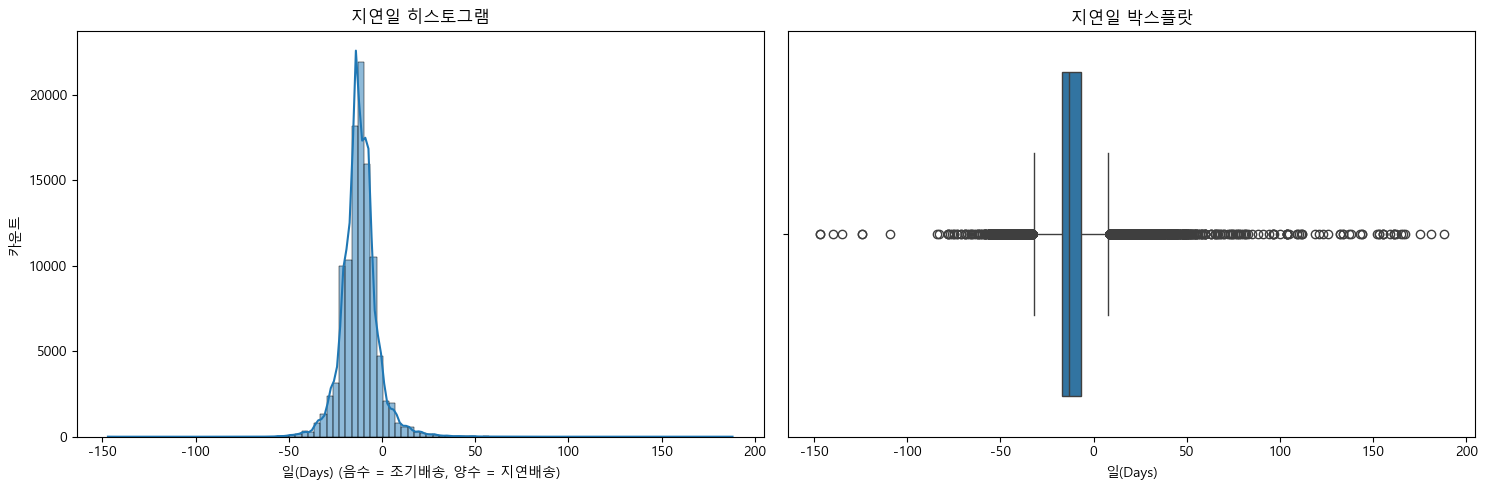

극단값 제거 전 데이터 개수: 107260건
기준: -60일 미만(너무 빠름) & 30일 초과(너무 늦음) 제거
극단값 제거 후 데이터 개수: 106872건
최종 마스터 테이블 크기: 26872행
지연 데이터 개수: 6718개
정상 데이터 개수(샘플링됨): 20154개


In [9]:
df_merged['delivery_delay_days'] = (df_merged['order_delivered_customer_date'] - df_merged['order_estimated_delivery_date']).dt.days

# 시각화
plt.figure(figsize=(15, 5))

# 히스토그램
plt.subplot(1, 2, 1)
sns.histplot(df_merged['delivery_delay_days'], bins=100, kde=True)
plt.title('지연일 히스토그램')
plt.xlabel('일(Days) (음수 = 조기배송, 양수 = 지연배송)')
plt.ylabel('카운트')

# 박스플롯
plt.subplot(1, 2, 2)
sns.boxplot(x=df_merged['delivery_delay_days'])
plt.title('지연일 박스플랏')
plt.xlabel('일(Days)')

plt.tight_layout()
plt.show()

# # 하위 1% / 상위 1%
# lower_bound = df_merged['delivery_delay_days'].quantile(0.01)
# upper_bound = df_merged['delivery_delay_days'].quantile(0.99)
# 하위 1% : -36.0
# 상위 1% : 18.0
# => 19일 지연 이런 데이터도 못보게 되는게 좀 아쉽다. 직접 기준을 정하기.

# 브라질에서 예상일을 길게 잡는 경우가 많다고 함.(약 2달)
lower_bound = -60
upper_bound = 30


print(f"극단값 제거 전 데이터 개수: {len(df_merged)}건")
print(f"기준: {lower_bound}일 미만(너무 빠름) & {upper_bound}일 초과(너무 늦음) 제거")


# 정상 범주에 있는 데이터만 남기기
df_merged = df_merged[(df_merged['delivery_delay_days'] >= lower_bound) & (df_merged['delivery_delay_days'] <= upper_bound)]
print(f"극단값 제거 후 데이터 개수: {len(df_merged)}건")

# 음수를 0으로 치환
df_merged['actual_delay_days'] = df_merged['delivery_delay_days'].apply(lambda x: x if x > 0 else 0)


# 1:3 언더샘플링 적용 (데이터 불균형 해소)
df_delayed = df_merged[df_merged['actual_delay_days'] > 0]
df_zero = df_merged[df_merged['actual_delay_days'] == 0]

# 정상 건(0)을 지연 건의 3배수만큼 무작위 추출
df_zero_sampled = df_zero.sample(n=len(df_delayed) * 3, random_state=42)

# 두 데이터 병합 및 셔플
df_final_master = pd.concat([df_delayed, df_zero_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print("="*60)
print(f"최종 마스터 테이블 크기: {df_final_master.shape[0]}행")
print(f"지연 데이터 개수: {len(df_delayed)}개")
print(f"정상 데이터 개수(샘플링됨): {len(df_zero_sampled)}개")


In [10]:
# 최종 타겟 - 지연 안 됨(0), 지연 됨(1)
df_final_master['is_delayed'] = df_final_master['actual_delay_days'].apply(lambda x: 1 if x > 0 else 0)


# 파생변수 추가
# 주문시점부터 예상 배송일까지의 기간(예상 배송 소요 일수)
df_final_master["estimated_delivery_gap"] = (
    df_final_master["order_estimated_delivery_date"] - 
    df_final_master["order_purchase_timestamp"]
).dt.days

# 거리 단위 로그 변환
df_final_master["distance_log"] = np.log1p(df_final_master["actual_distance_km"])

# 상품 밀도
df_final_master["volume_density"] = df_final_master["product_weight_g"] / (df_final_master["product_volume"] + 1)

# 상품 가격 대비 배송비 비율
df_final_master["freight_ratio"] = df_final_master["freight_value"] / (df_final_master["price"] + 1)

# 판매자와 고객이 같은 주(state)에 있는지 여부 (같으면 1, 다르면 0)
df_final_master["seller_customer_state_same"] = (
    df_final_master["seller_state"] == df_final_master["customer_state"]
).astype(int)

# 겨울 시즌 배송 거리 효과(겨울에는 같은 거리라도 배송 지연이 더 발생할 수 있지 않을까?)
df_final_master["distance_winter"] = df_final_master["actual_distance_km"] * (df_final_master["season"] == "Winter")

# 실제 배송 거리 대비 예상 배송 기간 비율 (거리/예상 배송일)
df_final_master["distance_gap_ratio"] = df_final_master["actual_distance_km"] / (df_final_master["estimated_delivery_gap"] + 1)

# km당 배송비 (배송비를 거리로 나눈 값)
df_final_master["freight_per_km"] = df_final_master["freight_value"] / (df_final_master["actual_distance_km"] + 1)

# 상품 가격 대비 무게 비율 (무게당 가격)
df_final_master["price_per_weight"] = df_final_master["price"] / (df_final_master["product_weight_g"] + 1)


# 버릴 컬럼 리스트
columns_to_drop = [
    'order_id', 'customer_id', 'order_status', 
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'shipping_limit_date', 
    'review_creation_date', # 날짜 원본 다 버림
    'customer_zip_code_prefix', 'customer_city', 
    'seller_zip_code_prefix', 'seller_city', # 위치 원본 다 버림
    'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', # 좌표 원본 버림
    'order_item_id', 'product_id', 'seller_id', 'review_id', # ID류 버림
    'product_length_cm', 'product_height_cm', 'product_width_cm', # 부피 원본 버림
    'review_score', # 데이터 누수 방지를 위해 버림
    'delivery_delay_days', 'actual_delay_days', # 이제 is_delayed 쓸 예정
    'order_month' # order_month_sin, order_month_cos
]

df_final_master = df_final_master.drop(columns=columns_to_drop)

print(f"남은 컬럼 수 : {len(df_final_master.columns)}")
print(f"남은 컬럼 : {df_final_master.columns.tolist()}")

남은 컬럼 수 : 24
남은 컬럼 : ['customer_state', 'price', 'freight_value', 'total_payment_value', 'product_weight_g', 'seller_state', 'product_category_name_english', 'actual_distance_km', 'product_volume', 'order_dayofweek', 'order_month_sin', 'order_month_cos', 'season', 'weekend', 'is_delayed', 'estimated_delivery_gap', 'distance_log', 'volume_density', 'freight_ratio', 'seller_customer_state_same', 'distance_winter', 'distance_gap_ratio', 'freight_per_km', 'price_per_weight']


In [11]:
#결측치 삭제
df_final_master = df_final_master.dropna()

#데이터 분할
X = df_final_master.drop(columns=['is_delayed'])
y = df_final_master['is_delayed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#범주형 변수
cat_cols = ['season', 'customer_state', 'seller_state', 'product_category_name_english']

# 원핫인코딩
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

#from lightgbm import LGBMClassifier

pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(random_state=42, n_jobs=-1))
])

param_distributions = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [15, 20, 25],
    'classifier__min_child_samples': [10, 20, 30],  # RF의 min_samples_split 대응
    'classifier__class_weight': ['balanced']
}

random_search_lgbm = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=param_distributions,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

best_model_lgbm = random_search_lgbm.best_estimator_
y_pred_lgbm = best_model_lgbm.predict(X_test)

print(f"최고 설정값: {random_search_lgbm.best_params_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lgbm):.4f}")

[LightGBM] [Info] Number of positive: 5289, number of negative: 15915
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005501 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3598
[LightGBM] [Info] Number of data points in the train set: 21204, number of used features: 112
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
최고 설정값: {'classifier__n_estimators': 200, 'classifier__min_child_samples': 20, 'classifier__max_depth': 25, 'classifier__class_weight': 'balanced'}
Accuracy: 0.7561
F1-Score: 0.5870


Test ROC-AUC 점수: 0.8119
Test PR-AUC 점수:  0.6044


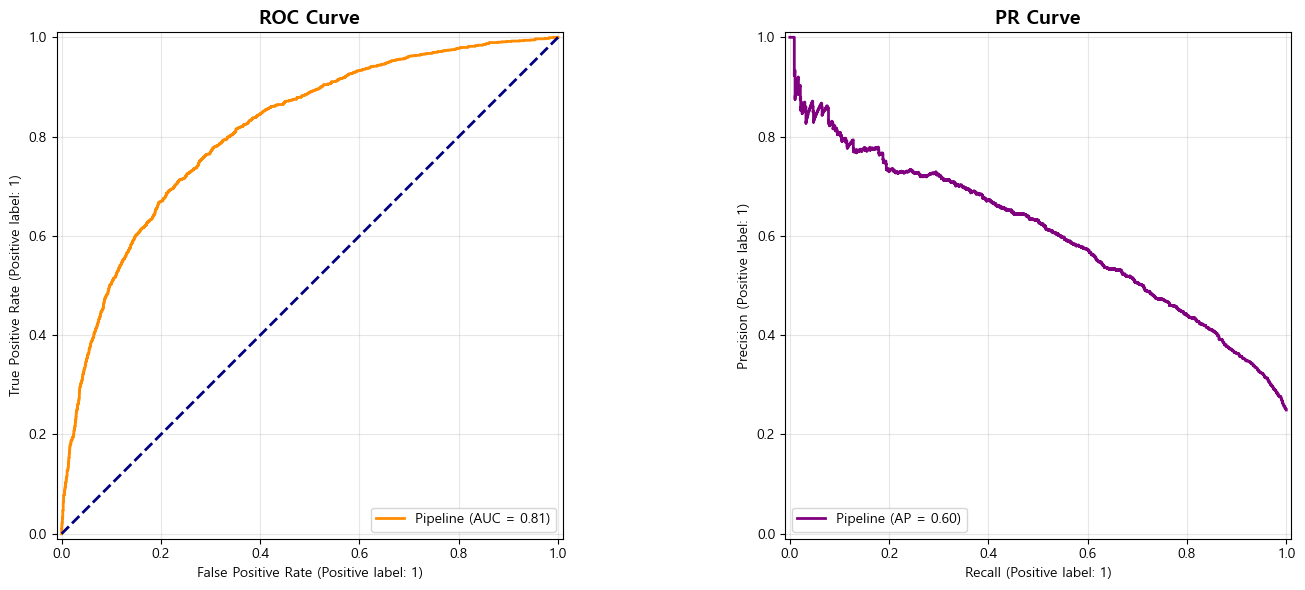

In [12]:
y_pred_proba = best_model_lgbm.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"Test ROC-AUC 점수: {roc_auc:.4f}")
print(f"Test PR-AUC 점수:  {pr_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

RocCurveDisplay.from_estimator(best_model_lgbm, X_test, y_test, color='darkorange', lw=2, ax=axes[0])
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

PrecisionRecallDisplay.from_estimator(best_model_lgbm, X_test, y_test, color='purple', lw=2, ax=axes[1])
axes[1].set_title('PR Curve', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Train 학습 및 점수
y_train_pred = best_model_lgbm.predict(X_train)
y_train_pred_proba = best_model_lgbm.predict_proba(X_train)[:, 1]

train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)
train_pr_auc = average_precision_score(y_train, y_train_pred_proba)

# Test 점수
y_test_pred_proba = best_model_lgbm.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred_lgbm)
test_f1 = f1_score(y_test, y_pred_lgbm)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
test_pr_auc = average_precision_score(y_test, y_test_pred_proba)

print("과적합(Overfitting) 검사")
print("="*60)
print(f"[Accuracy]  연습(Train): {train_acc:.4f}  vs  실전(Test): {test_acc:.4f}")
print(f"[F1-Score]  연습(Train): {train_f1:.4f}  vs  실전(Test): {test_f1:.4f}")
print(f"[ROC-AUC]   연습(Train): {train_roc_auc:.4f}  vs  실전(Test): {test_roc_auc:.4f}")
print(f"[PR-AUC]   연습(Train): {train_pr_auc:.4f}  vs  실전(Test): {test_pr_auc:.4f}")

과적합(Overfitting) 검사
[Accuracy]  연습(Train): 0.8520  vs  실전(Test): 0.7561
[F1-Score]  연습(Train): 0.7464  vs  실전(Test): 0.5870
[ROC-AUC]   연습(Train): 0.9366  vs  실전(Test): 0.8119
[PR-AUC]   연습(Train): 0.8310  vs  실전(Test): 0.6044


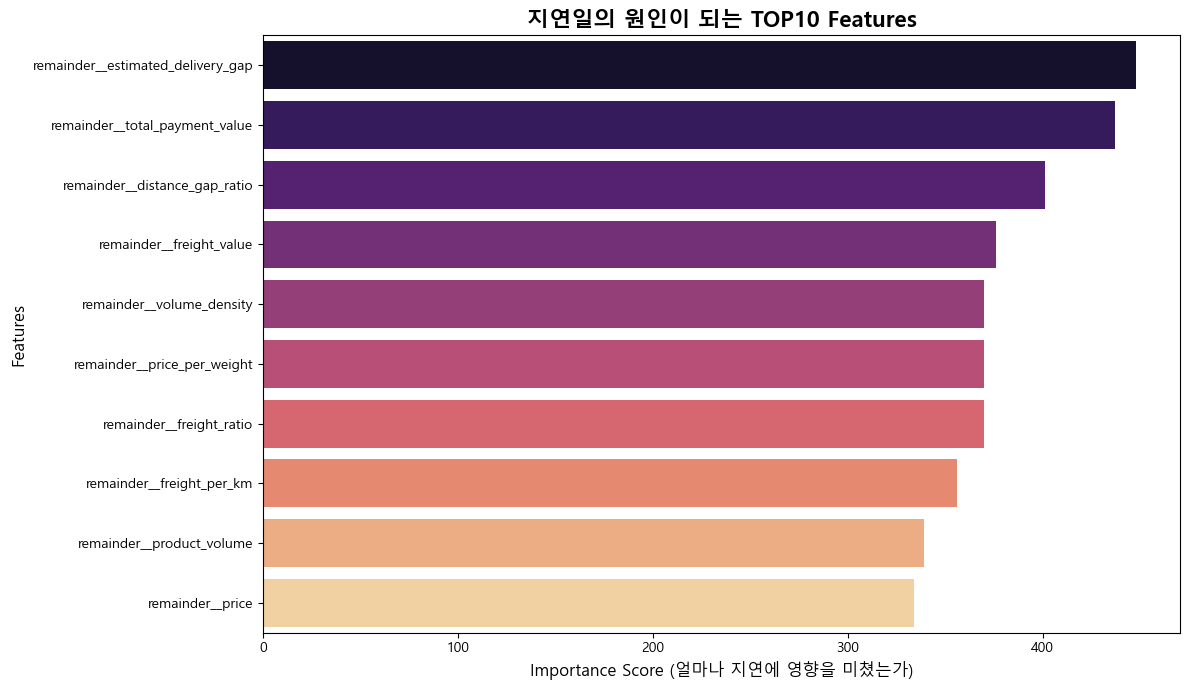

In [14]:
# preprocessor와 classifier 분리
preprocessor_final = best_model_lgbm.named_steps['preprocessor']
lgbm_final = best_model_lgbm.named_steps['classifier']

# 컬럼 이름들 가져오기
feature_names = preprocessor_final.get_feature_names_out()

# Feature Importance
importances = lgbm_final.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 상위 10개 시각화
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('지연일의 원인이 되는 TOP10 Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (얼마나 지연에 영향을 미쳤는가)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import chi2_contingency
import numpy as np

# customer_state_SP 생성
df_final_master['customer_state_SP'] = (df_final_master['customer_state'] == 'SP').astype(int)

# 카이제곱 검정
ct = pd.crosstab(df_final_master['customer_state_SP'], df_final_master['is_delayed'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'chi2: {chi2:.4f}, p-value: {p:.4f}')

# 효과 크기 (Cramer's V)
n = len(df_final_master)
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Cramer's V: {cramers_v:.4f}")

chi2: 473.6160, p-value: 0.0000
Cramer's V: 0.1337
